In [1]:
import timm
import torch
import matplotlib.pyplot as plt
from FineTuneUtils import EarlyStopping, train_model, eval_loop, check_top5_accuracy
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from torch.optim import AdamW, lr_scheduler
from torch.nn import CrossEntropyLoss


In [2]:
#creazione del modello
device = "cuda" if torch.cuda.is_available() else "cpu"
num_classes = 200
model = timm.create_model("vit_small_patch16_224", pretrained=True, num_classes=num_classes).to(device)

In [3]:
#creazione delle trasformazioni
#si usano media e deviazione standard di imagenet su cui il modello è preaddestrato

data_config = timm.data.resolve_model_data_config(model)
imagenet_mean, imagenet_std = data_config["mean"], data_config["std"]

test_transform = transforms.Compose(
    [transforms.Resize((224, 224)), transforms.ToTensor(), transforms.Normalize(mean=imagenet_mean, std=imagenet_std)])

val_transform = transforms.Compose(
    [transforms.ToTensor(), transforms.Normalize(mean=imagenet_mean, std=imagenet_std)])


train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

In [4]:
batch_size = 128
N_epochs = 15
backbone_lr = 1e-6
head_lr = 1e-5
weight_decay = 0.1

In [5]:
#creazione dei dataset e dataloader

train_set = ImageFolder("D:\\Tesi\\Sets\\Set1\\train", transform=train_transform)
val_set = ImageFolder("D:\\Tesi\\Sets\\Set1\\val", transform=val_transform)
test_set = ImageFolder("D:\\Tesi\\Places365Simplified\\val", transform=test_transform)

classes = train_set.classes

train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False)

In [6]:
#discriminative learning rates

#prelevo i pesi della backbone controllando che non siano quelli della head
head_params_pointers = set(p.data_ptr() for p in model.head.parameters())
backbone_params = [p for p in model.parameters() if p.data_ptr() not in head_params_pointers]

param_groups = [
    {
        "params": backbone_params,
        "lr": backbone_lr,
    },
    {
        "params": model.head.parameters(),
        "lr": head_lr,
    }
]

optim = AdamW(param_groups, weight_decay=weight_decay)
scheduler = lr_scheduler.CosineAnnealingLR(optim, T_max=N_epochs, eta_min=1e-7)
loss_fn = CrossEntropyLoss()

In [7]:
early_stopping = EarlyStopping(path="D:\\Tesi\\FirstFineTuning", patience=3 ,min_delta=0.01)

train_loss, val_loss, accuracy = train_model(model, N_epochs, optimizer=optim, device=device,
                                             train_dataloader=train_loader, loss_fn=loss_fn,
                                             early_stopping=early_stopping, val_dataloader=val_loader,
                                             scheduler=scheduler)

Epoch 1:   7%|▋         | 242/3666 [01:02<14:42,  3.88it/s]


KeyboardInterrupt: 

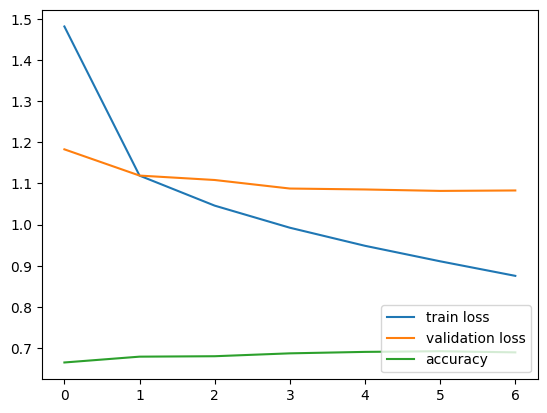

In [ ]:
plt.plot(train_loss, label="train loss")
plt.plot(val_loss, label="validation loss")
plt.plot(accuracy, label='accuracy')
plt.legend(loc='lower right')
plt.show()

In [8]:
checkpoint = torch.load("D:\\Tesi\\FirstFineTuning\\best_model.pth")
model.load_state_dict(checkpoint['model_state_dict'])
_, _, y_true, y_pred = eval_loop(model, val_loader, loss_fn, device, classes, report=True)
print(f"Top5 accuracy: {check_top5_accuracy(model, val_loader, device):.2f}%")

                            precision    recall  f1-score   support

                  airfield      0.906     0.920     0.913       125
          airport_terminal      0.638     0.720     0.677       125
                     alley      0.596     0.768     0.671       125
              amphitheater      0.744     0.768     0.756       125
          amusement_arcade      0.802     0.776     0.789       125
            amusement_park      0.677     0.720     0.698       125
apartment_building-outdoor      0.583     0.592     0.587       125
                  aquarium      0.791     0.728     0.758       125
                  aqueduct      0.680     0.696     0.688       125
  archaelogical_excavation      0.676     0.552     0.608       125
                   archive      0.705     0.632     0.667       125
         arena-performance      0.683     0.656     0.669       125
               arena-rodeo      0.895     0.888     0.892       125
                 army_base      0.890     0.840